# CMP461 Pattern Recognition - Midterm Project
## Phase 1: Data Preprocessing (Veri Ön İşleme)

**Author:** Efe Yaşar  
**Student ID:** 210408030  

--- 

### Project Overview / Proje Özeti
This notebook handles the initial stage of our animal classification project. We are processing a dataset of Cats, Dogs, and Snakes. Our objective here is to load, clean, resize, and normalize these images to ensure optimal performance for our upcoming Neural Network models.

Bu notebook, hayvan sınıflandırma projemizin başlangıç aşamasını ele almaktadır. Kedi, Köpek ve Yılanlardan oluşan bir veri setini işliyoruz. Buradaki amacımız, gelecek Sinir Ağı modellerimiz için en iyi performansı sağlamak amacıyla bu görüntüleri yüklemek, temizlemek, yeniden boyutlandırmak ve normalize etmektir.

In [6]:
# --- STEP 1: Imports and Configurations ---
# --- ADIM 1: Kütüphaneler ve Yapılandırma ---

import os
import numpy as np
import matplotlib.pyplot as plt
import cv2
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import tensorflow as tf
from tqdm import tqdm

# Setting global constants for consistency / Tutarlılık için genel sabitleri belirliyoruz
IMG_SIZE = 128
DATASET_DIR = "DATASET"
CLASSES = ["cats", "dogs", "snakes"]
OUTPUT_DIR = "results/preprocessing"

# Creative structural setup / Profesyonel klasör yapısı kurulumu
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs("models", exist_ok=True)

print("✅ Environment ready. / Ortam hazır.")

✅ Environment ready. / Ortam hazır.


In [7]:
# --- STEP 2: Loading Data ---
# --- ADIM 2: Veri Yükleme ---

def load_data():
    """
    Reads images, converts to RGB, and resizes them.
    Resimleri okur, RGB'ye dönüştürür ve boyutlandırır.
    """
    X = []
    y = []
    
    print("🚀 Loading dataset... / Veri seti yükleniyor...")
    for index, category in enumerate(CLASSES):
        path = os.path.join(DATASET_DIR, category)
        if not os.path.exists(path):
            print(f"⚠️ Warning: Path {path} not found!")
            continue
            
        print(f"📂 Processing: {category}")
        for img_name in tqdm(os.listdir(path)):
            try:
                img_path = os.path.join(path, img_name)
                # Load image / Görseli yükle
                img = cv2.imread(img_path)
                if img is None: continue
                
                # BGR to RGB and Resize / BGR'den RGB'ye dönüştür ve boyutlandır
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
                
                X.append(img)
                y.append(index)
            except:
                continue
                
    return np.array(X), np.array(y)

X, y = load_data()
print(f"\n✅ Sub-total: {len(X)} images. / Toplam: {len(X)} görsel.")

🚀 Loading dataset... / Veri seti yükleniyor...
📂 Processing: cats


100%|██████████| 1000/1000 [00:00<00:00, 2032.08it/s]


📂 Processing: dogs


100%|██████████| 1000/1000 [00:00<00:00, 1933.98it/s]


📂 Processing: snakes


100%|██████████| 1000/1000 [00:00<00:00, 1492.32it/s]



✅ Sub-total: 3000 images. / Toplam: 3000 görsel.


In [8]:
# --- STEP 3: Splitting and Normalizing ---
# --- ADIM 3: Bölme ve Normalizasyon ---

# 70% Train, 15% Val, 15% Test split / %70 Eğitim, %15 Doğrulama, %15 Test ayrımı
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print(f"📊 Training: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")

# Pixel normalization [0, 1] / Piksel normalizasyonu [0, 1]
X_train = X_train.astype('float32') / 255.0
X_val = X_val.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

📊 Training: 2100 | Val: 450 | Test: 450


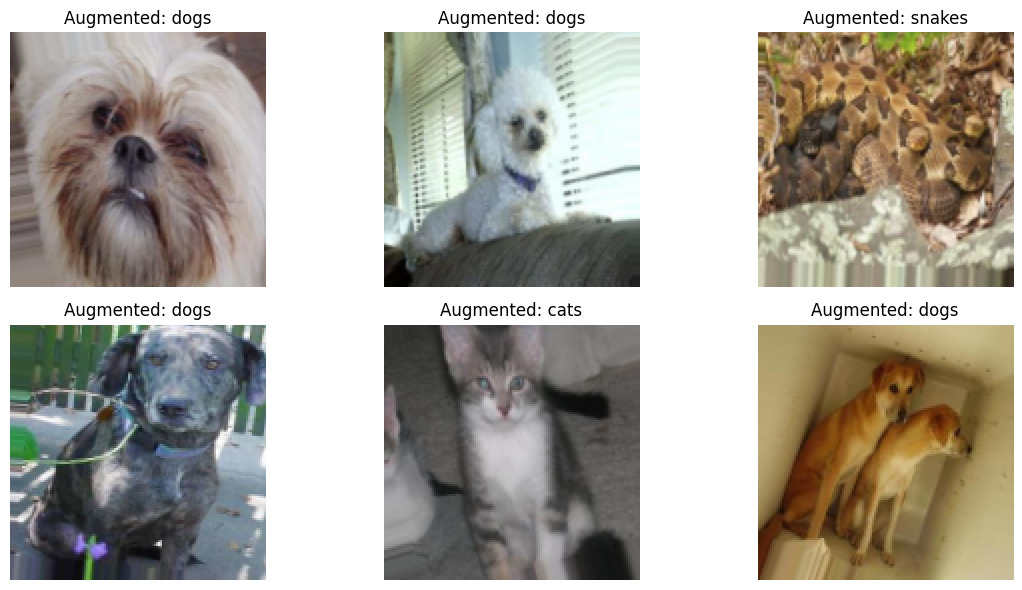

In [9]:
# --- STEP 4: Augmentation Visualization ---
# --- ADIM 4: Veri Arttırma Görselleştirme ---

datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

plt.figure(figsize=(12, 6))
for i in range(6):
    plt.subplot(2, 3, i+1)
    img_array = X_train[i].reshape((1, IMG_SIZE, IMG_SIZE, 3))
    aug_iter = datagen.flow(img_array, batch_size=1)
    aug_img = next(aug_iter)[0]
    plt.imshow(aug_img)
    plt.axis('off')
    plt.title(f"Augmented: {CLASSES[y_train[i]]}")

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "augmentation_samples.png"))
plt.show()

In [10]:
# --- STEP 5: Final Save ---
# --- ADIM 5: Final Kayıt ---

np.savez_compressed("preprocessed_data.npz", 
                    X_train=X_train, y_train=y_train, 
                    X_val=X_val, y_val=y_val, 
                    X_test=X_test, y_test=y_test)

print("💾 Data saved to preprocessed_data.npz successfully!")

💾 Data saved to preprocessed_data.npz successfully!
